In [1]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 5.3 MB/s eta 0:00:00


In [2]:
# 1. Import Library
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import eli5
from eli5.sklearn import PermutationImportance


# Set default visual theme
sns.set(style="whitegrid")


In [3]:
df = pd.read_csv('incom2024_delay_example_dataset.csv')

<ipython-input-4-cf4b35188ba1>:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['order_month'] = df['order_date'].dt.to_period('M').astype(str)


Korelasi delay bulan sebelumnya terhadap sales bulan ini: 0.0958
Korelasi delay bulan sebelumnya terhadap profit bulan ini: 0.0864


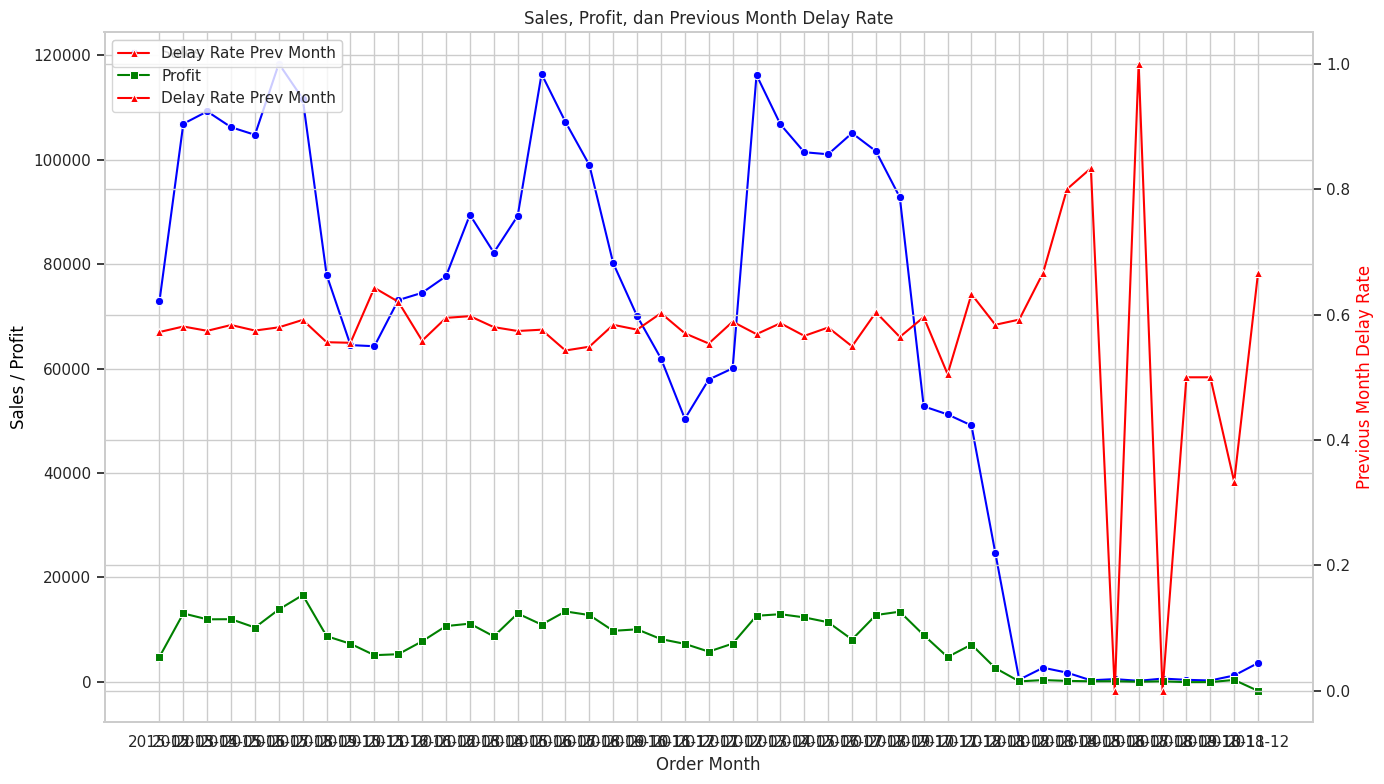

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pastikan order_date dalam datetime (dengan aman)
df['order_date'] = pd.to_datetime(df['order_date'], utc=True, errors='coerce')

# --- Buang data NaT kalau ada yang gagal parsing
df = df.dropna(subset=['order_date'])

# --- Hitung total order
total_orders = len(df)

# --- Hitung jumlah delay
total_delayed_orders = (df['label'] == 1).sum()

# --- Hitung persentase delay
delay_percentage = (total_delayed_orders / total_orders) * 100

# --- Buat order_month
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)

# --- Hitung sales per bulan
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

# --- Hitung profit per bulan
monthly_profit = df.groupby('order_month')['order_profit_per_order'].sum().reset_index()

# --- Hitung delay rate per bulan
monthly_delay = df.groupby('order_month')['label'].apply(lambda x: (x == 1).mean()).reset_index()
monthly_delay.rename(columns={'label': 'delay_rate'}, inplace=True)

# --- Gabungkan semuanya
monthly_data = monthly_sales.merge(monthly_profit, on='order_month').merge(monthly_delay, on='order_month')

# --- Geser delay rate ke bulan berikutnya
monthly_data['prev_month_delay_rate'] = monthly_data['delay_rate'].shift(1)

# --- Hapus bulan pertama yang tidak punya prev_month_delay_rate
monthly_data = monthly_data.dropna()

# --- Hitung korelasi
corr_sales = monthly_data['prev_month_delay_rate'].corr(monthly_data['sales'])
corr_profit = monthly_data['prev_month_delay_rate'].corr(monthly_data['order_profit_per_order'])

print(f"Korelasi delay bulan sebelumnya terhadap sales bulan ini: {corr_sales:.4f}")
print(f"Korelasi delay bulan sebelumnya terhadap profit bulan ini: {corr_profit:.4f}")

# --- Plot grafik
plt.figure(figsize=(14,8))

# Grafik Sales dan Profit
ax1 = sns.lineplot(x='order_month', y='sales', data=monthly_data, marker='o', label='Sales', color='blue')
sns.lineplot(x='order_month', y='order_profit_per_order', data=monthly_data, marker='s', label='Profit', color='green', ax=ax1)

# Grafik Delay Rate pada twin axis
ax2 = ax1.twinx()
sns.lineplot(x='order_month', y='prev_month_delay_rate', data=monthly_data, marker='^', label='Delay Rate Prev Month', color='red', ax=ax2)

# Setting labels
ax1.set_ylabel('Sales / Profit', color='black')
ax2.set_ylabel('Previous Month Delay Rate', color='red')
ax1.set_xlabel('Order Month')

# Title dan Grid
plt.title('Sales, Profit, dan Previous Month Delay Rate')
ax1.grid(True)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Gabungkan legend dari dua axis
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()


In [5]:
# --- Generate laporan otomatis
laporan = f"""
📋 ANALISIS DELAY BERDASARKAN DATA

1. Dari total {total_orders:,} transaksi, terdapat {total_delayed_orders:,} transaksi yang mengalami keterlambatan, yaitu sebesar {delay_percentage:.2f}% dari keseluruhan data.

2. Hasil analisis korelasi:
   - Korelasi antara tingkat keterlambatan bulan sebelumnya dengan sales bulan ini: {corr_sales:.4f}
   - Korelasi antara tingkat keterlambatan bulan sebelumnya dengan profit bulan ini: {corr_profit:.4f}

3. Interpretasi:
   - Korelasi yang ditemukan tergolong sangat kecil, menunjukkan bahwa saat ini tingkat keterlambatan belum berdampak signifikan terhadap penjualan maupun profit bulanan.
   - Meskipun demikian, tingginya persentase keterlambatan tetap menjadi faktor risiko yang berpotensi merusak loyalitas pelanggan dan pertumbuhan bisnis jangka panjang.

4. Rekomendasi:
   - Disarankan untuk memonitor tingkat keterlambatan secara berkala.
   - Mengoptimalkan proses pengiriman guna menjaga kepuasan pelanggan dan mengurangi risiko kerugian di masa mendatang.

✅ Analisis berbasis data ini menunjukkan pentingnya perhatian terhadap pengelolaan waktu pengiriman meskipun dampak langsungnya saat ini belum terlihat signifikan.
"""

print(laporan)



📋 ANALISIS DELAY BERDASARKAN DATA

1. Dari total 15,549 transaksi, terdapat 8,976 transaksi yang mengalami keterlambatan, yaitu sebesar 57.73% dari keseluruhan data.

2. Hasil analisis korelasi:
   - Korelasi antara tingkat keterlambatan bulan sebelumnya dengan sales bulan ini: 0.0958
   - Korelasi antara tingkat keterlambatan bulan sebelumnya dengan profit bulan ini: 0.0864

3. Interpretasi:
   - Korelasi yang ditemukan tergolong sangat kecil, menunjukkan bahwa saat ini tingkat keterlambatan belum berdampak signifikan terhadap penjualan maupun profit bulanan.
   - Meskipun demikian, tingginya persentase keterlambatan tetap menjadi faktor risiko yang berpotensi merusak loyalitas pelanggan dan pertumbuhan bisnis jangka panjang.

4. Rekomendasi:
   - Disarankan untuk memonitor tingkat keterlambatan secara berkala.
   - Mengoptimalkan proses pengiriman guna menjaga kepuasan pelanggan dan mengurangi risiko kerugian di masa mendatang.

✅ Analisis berbasis data ini menunjukkan pentingnya pe

In [6]:
# 3. Data Type Fixing & Parsing Dates
# ======================================
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', utc=True)
df['shipping_date'] = pd.to_datetime(df['shipping_date'], errors='coerce', utc=True)
df['shipping_duration'] = (df['shipping_date'] - df['order_date']).dt.days


In [7]:
# 4. Data Cleaning
# ======================================
rows_before = df.shape[0]
df_clean = df.dropna(subset=['order_date', 'shipping_date'])
df_clean = df_clean[df_clean['shipping_duration'] > 0]
rows_after = df_clean.shape[0]
print(f"Dropped rows due to invalid/missing dates or non-positive duration: {rows_before - rows_after} ({(rows_before - rows_after)/rows_before:.2%})")


Dropped rows due to invalid/missing dates or non-positive duration: 6090 (39.17%)


In [8]:
print("Distribusi label sebelum cleaning:")
print(df['label'].value_counts(normalize=True))

print("\nDistribusi label setelah cleaning:")
print(df_clean['label'].value_counts(normalize=True))


Distribusi label sebelum cleaning:
label
 1    0.577272
-1    0.227989
 0    0.194739
Name: proportion, dtype: float64

Distribusi label setelah cleaning:
label
 1    0.580611
-1    0.232160
 0    0.187229
Name: proportion, dtype: float64


In [9]:
print("Distribusi label sebelum cleaning:")
print(df['label'].value_counts(normalize=True))

print("\nDistribusi label setelah cleaning:")
print(df_clean['label'].value_counts(normalize=True))


Distribusi label sebelum cleaning:
label
 1    0.577272
-1    0.227989
 0    0.194739
Name: proportion, dtype: float64

Distribusi label setelah cleaning:
label
 1    0.580611
-1    0.232160
 0    0.187229
Name: proportion, dtype: float64


<ipython-input-10-6b9ff97e2169>:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Month'] = df['order_date'].dt.to_period('M')


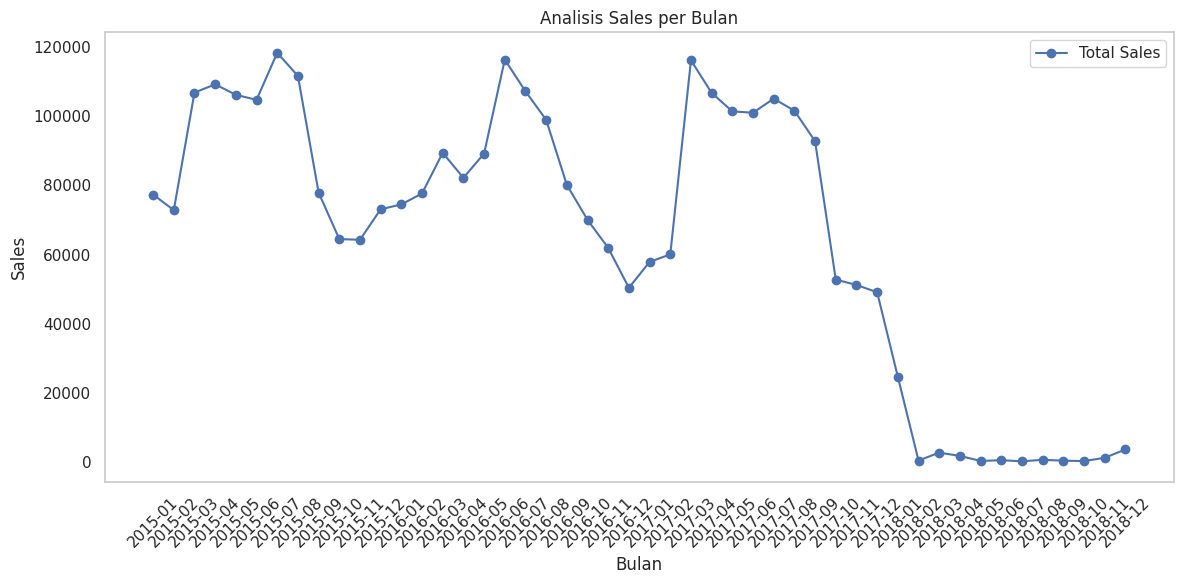

In [10]:
# 5. Exploratory Data Analysis (EDA)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan 'order_date' jadi datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Buat kolom bulan-tahun
df['Month'] = df['order_date'].dt.to_period('M')

# 3. Group by bulan
monthly_data = df.groupby('Month').agg({
    'sales': 'sum',
}).reset_index()

# 4. Rename kolom biar rapi
monthly_data.rename(columns={
    'sales': 'Total Sales',
}, inplace=True)

# 5. Plot Sales dan Profit
plt.figure(figsize=(12,6))
plt.plot(monthly_data['Month'].astype(str), monthly_data['Total Sales'], label='Total Sales', marker='o')
plt.title('Analisis Sales per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


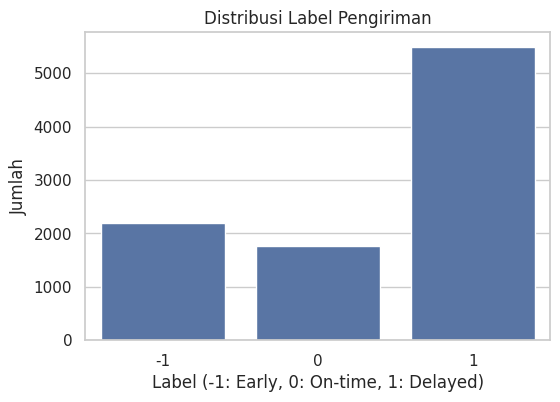

In [11]:
# 5.1 Distribusi target label
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_clean)
plt.title('Distribusi Label Pengiriman')
plt.xlabel('Label (-1: Early, 0: On-time, 1: Delayed)')
plt.ylabel('Jumlah')
plt.show()

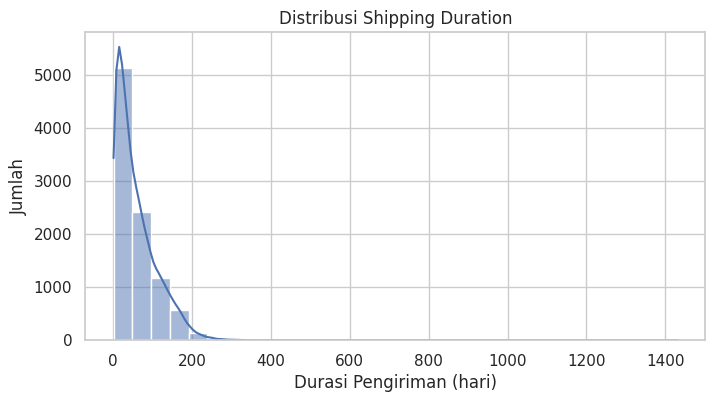

In [12]:
# 5.2 Distribusi durasi pengiriman
plt.figure(figsize=(8,4))
sns.histplot(df_clean['shipping_duration'], bins=30, kde=True)
plt.title('Distribusi Shipping Duration')
plt.xlabel('Durasi Pengiriman (hari)')
plt.ylabel('Jumlah')
plt.show()

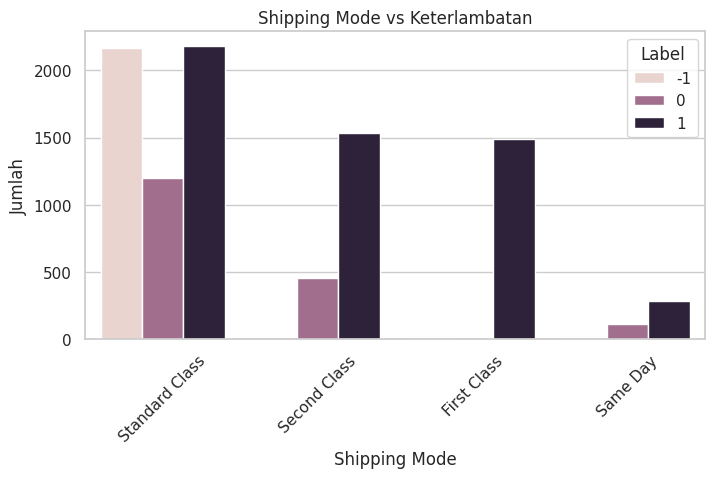

In [13]:
# 5.3 Shipping Mode vs Delay
plt.figure(figsize=(8,4))
sns.countplot(x='shipping_mode', hue='label', data=df_clean)
plt.title('Shipping Mode vs Keterlambatan')
plt.xlabel('Shipping Mode')
plt.ylabel('Jumlah')
plt.legend(title='Label')
plt.xticks(rotation=45)
plt.show()

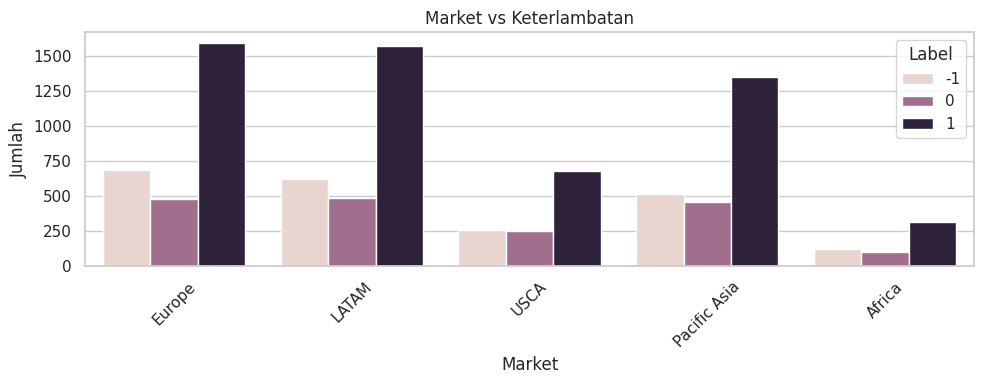

In [14]:
# 5.4 Market vs Delay
plt.figure(figsize=(10,4))
sns.countplot(x='market', hue='label', data=df_clean)
plt.title('Market vs Keterlambatan')
plt.xlabel('Market')
plt.ylabel('Jumlah')
plt.legend(title='Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-15-710e4821214f>:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['order_month_year'] = df['order_date'].dt.to_period('M').astype(str)


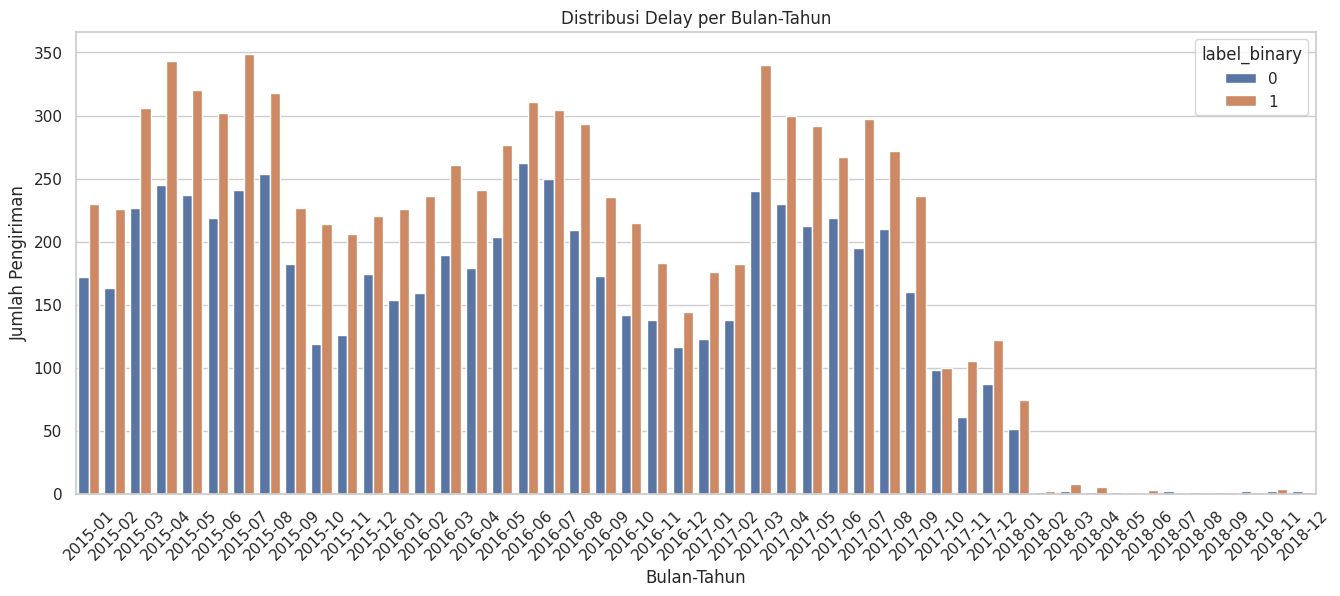

In [15]:
# 5.5 Bulan vs Delay
# Buat kolom baru: order_month_year
df['order_month_year'] = df['order_date'].dt.to_period('M').astype(str)

# Urutkan data berdasarkan order_month_year
df = df.sort_values('order_month_year')

# Buat kolom 'label_binary' jika belum ada
if 'label_binary' not in df.columns:
    df['label_binary'] = df['label'].apply(lambda x: 1 if x == 1 else 0)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.countplot(x='order_month_year', hue='label_binary', data=df, order=df['order_month_year'].sort_values().unique())
plt.title('Distribusi Delay per Bulan-Tahun')
plt.xlabel('Bulan-Tahun')
plt.ylabel('Jumlah Pengiriman')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:40:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost Binary,0.718288,0.725470,0.718288,0.719920
1,Random Forest,0.715116,0.722510,0.715116,0.716784
2,K-Nearest Neighbors,0.685518,0.689766,0.685518,0.686885


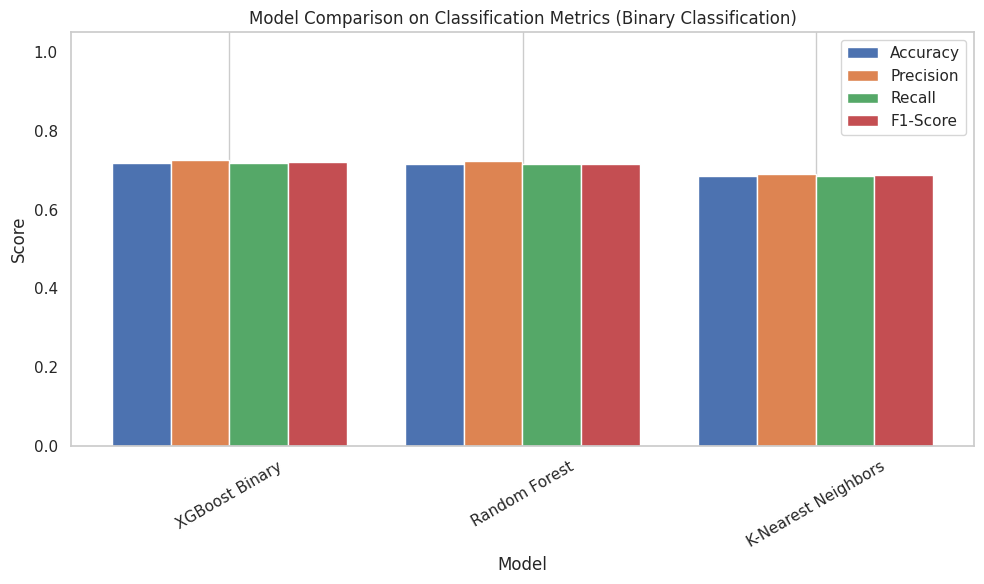

In [16]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# ======================================
# 1. Fitur yang dipakai
# ======================================

categorical_features = ['shipping_mode', 'market', 'order_status', 'customer_segment']
numerical_features = ['order_item_discount_rate', 'product_price', 'sales', 'shipping_duration']

# Dataset bersih
model_df = df_clean[categorical_features + numerical_features + ['label']].dropna()
X = model_df.drop('label', axis=1)
y = model_df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ======================================
# 2. Preprocessing
# ======================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# ======================================
# 3. Buat label binary
# ======================================

# Label binary: 0 = Not Late (-1 & 0), 1 = Late (1)
df_clean['label_binary'] = df_clean['label'].apply(lambda x: 1 if x == 1 else 0)

model_df_binary = df_clean[categorical_features + numerical_features + ['label_binary']].dropna()
X_bin = model_df_binary.drop('label_binary', axis=1)
y_bin = model_df_binary['label_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# Transform
X_train_transformed = preprocessor.fit_transform(X_train_bin)
X_test_transformed = preprocessor.transform(X_test_bin)

# ======================================
# 4. Train Model dan Ranking
# ======================================

# Definisikan model (XGBoost Binary di urutan pertama)
models = {
    "XGBoost Binary": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Simpan hasil evaluasi
results = []

for name, model in models.items():
    model.fit(X_train_transformed, y_train_bin)
    y_pred = model.predict(X_test_transformed)

    acc = accuracy_score(y_test_bin, y_pred)
    prec = precision_score(y_test_bin, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test_bin, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_bin, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# ======================================
# 5. Tampilkan Hasil
# ======================================

# DataFrame ranking
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

display(results_df)

# Plot
plt.figure(figsize=(10,6))
bar_width = 0.2
x = range(len(results_df))

plt.bar(x, results_df["Accuracy"], width=bar_width, label="Accuracy")
plt.bar([i + bar_width for i in x], results_df["Precision"], width=bar_width, label="Precision")
plt.bar([i + 2*bar_width for i in x], results_df["Recall"], width=bar_width, label="Recall")
plt.bar([i + 3*bar_width for i in x], results_df["F1-Score"], width=bar_width, label="F1-Score")

plt.xticks([i + 1.5*bar_width for i in x], results_df["Model"], rotation=30)
plt.title("Model Comparison on Classification Metrics (Binary Classification)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [17]:
categorical_features = ['shipping_mode', 'market', 'order_status', 'customer_segment']
numerical_features = ['order_item_discount_rate', 'product_price', 'sales', 'shipping_duration']

model_df = df_clean[categorical_features + numerical_features + ['label']].dropna()
X = model_df.drop('label', axis=1)
y = model_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [18]:
# Split data
X = model_df.drop('label', axis=1)
y = model_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train model
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          -1       0.44      0.55      0.49       439
           0       0.21      0.08      0.11       354
           1       0.70      0.78      0.74      1099

    accuracy                           0.59      1892
   macro avg       0.45      0.47      0.45      1892
weighted avg       0.55      0.59      0.56      1892

Confusion Matrix:
[[242  43 154]
 [119  27 208]
 [187  58 854]]


In [19]:
# 8. Model Alternatif - XGBoost
# ======================================
# Mapping label ke 0,1,2 untuk XGBoost
label_mapping = {-1: 0, 0: 1, 1: 2}
y_train_xgb = y_train.map(label_mapping)
y_test_xgb = y_test.map(label_mapping)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

xgb_pipeline.fit(X_train, y_train_xgb)
y_xgb_pred = xgb_pipeline.predict(X_test)

# Kembalikan ke label asli untuk evaluasi
y_xgb_pred_original = pd.Series(y_xgb_pred).map({0: -1, 1: 0, 2: 1})

print("\n[XGBoost] Classification Report:")
print(classification_report(y_test, y_xgb_pred_original))
print("[XGBoost] Confusion Matrix:")
print(confusion_matrix(y_test, y_xgb_pred_original))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:40:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



[XGBoost] Classification Report:
              precision    recall  f1-score   support

          -1       0.45      0.58      0.51       439
           0       0.22      0.07      0.11       354
           1       0.71      0.77      0.74      1099

    accuracy                           0.60      1892
   macro avg       0.46      0.48      0.45      1892
weighted avg       0.55      0.60      0.57      1892

[XGBoost] Confusion Matrix:
[[256  42 141]
 [115  25 214]
 [201  47 851]]


In [20]:

# ======================================
# 8.1 Model Alternatif - XGBoost + SMOTE
# ======================================
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# Transform data menggunakan preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Oversample dengan SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_transformed, y_train_xgb)

# Train ulang XGBoost di data yang sudah dioversample
xgb_smote_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_smote_model.fit(X_resampled, y_resampled)

# Prediksi
y_smote_pred = xgb_smote_model.predict(X_test_transformed)
y_smote_pred_original = pd.Series(y_smote_pred).map({0: -1, 1: 0, 2: 1})

# Evaluasi
print("\n[XGBoost + SMOTE] Classification Report:")
print(classification_report(y_test, y_smote_pred_original))
print("[XGBoost + SMOTE] Confusion Matrix:")
print(confusion_matrix(y_test, y_smote_pred_original))



[XGBoost + SMOTE] Classification Report:
              precision    recall  f1-score   support

          -1       0.45      0.64      0.53       439
           0       0.26      0.12      0.17       354
           1       0.74      0.74      0.74      1099

    accuracy                           0.60      1892
   macro avg       0.48      0.50      0.48      1892
weighted avg       0.58      0.60      0.58      1892

[XGBoost + SMOTE] Confusion Matrix:
[[281  56 102]
 [127  43 184]
 [216  66 817]]


In [21]:

# ======================================
# 8.2 Binary Classification: Not Late (0) vs Late (1)
# ======================================

# Gabungkan label menjadi binary: 0 = Not Late (-1 & 0), 1 = Late (1)
df_clean['label_binary'] = df_clean['label'].apply(lambda x: 1 if x == 1 else 0)

# Data untuk model binary
model_df_binary = df_clean[categorical_features + numerical_features + ['label_binary']].dropna()
X_bin = model_df_binary.drop('label_binary', axis=1)
y_bin = model_df_binary['label_binary']

# Split data
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)


In [22]:
# Preprocessing untuk X_train sebelum SMOTE
X_train_bin_preprocessed = preprocessor.fit_transform(X_train_bin)
X_test_bin_preprocessed = preprocessor.transform(X_test_bin)

# SMOTE setelah preprocessing
X_res_bin, y_res_bin = SMOTE(random_state=42).fit_resample(X_train_bin_preprocessed, y_train_bin)

# Model XGBoost langsung (tanpa pipeline karena sudah preprocessed)
xgb_bin = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_bin.fit(X_res_bin, y_res_bin)

# Predict
y_bin_pred = xgb_bin.predict(X_test_bin_preprocessed)

# Evaluasi
print("[XGBoost Binary] Classification Report:")
print(classification_report(y_test_bin, y_bin_pred))
print("[XGBoost Binary] Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_bin_pred))


[XGBoost Binary] Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.76      0.70       793
           1       0.80      0.71      0.75      1099

    accuracy                           0.73      1892
   macro avg       0.73      0.73      0.73      1892
weighted avg       0.74      0.73      0.73      1892

[XGBoost Binary] Confusion Matrix:
[[603 190]
 [323 776]]


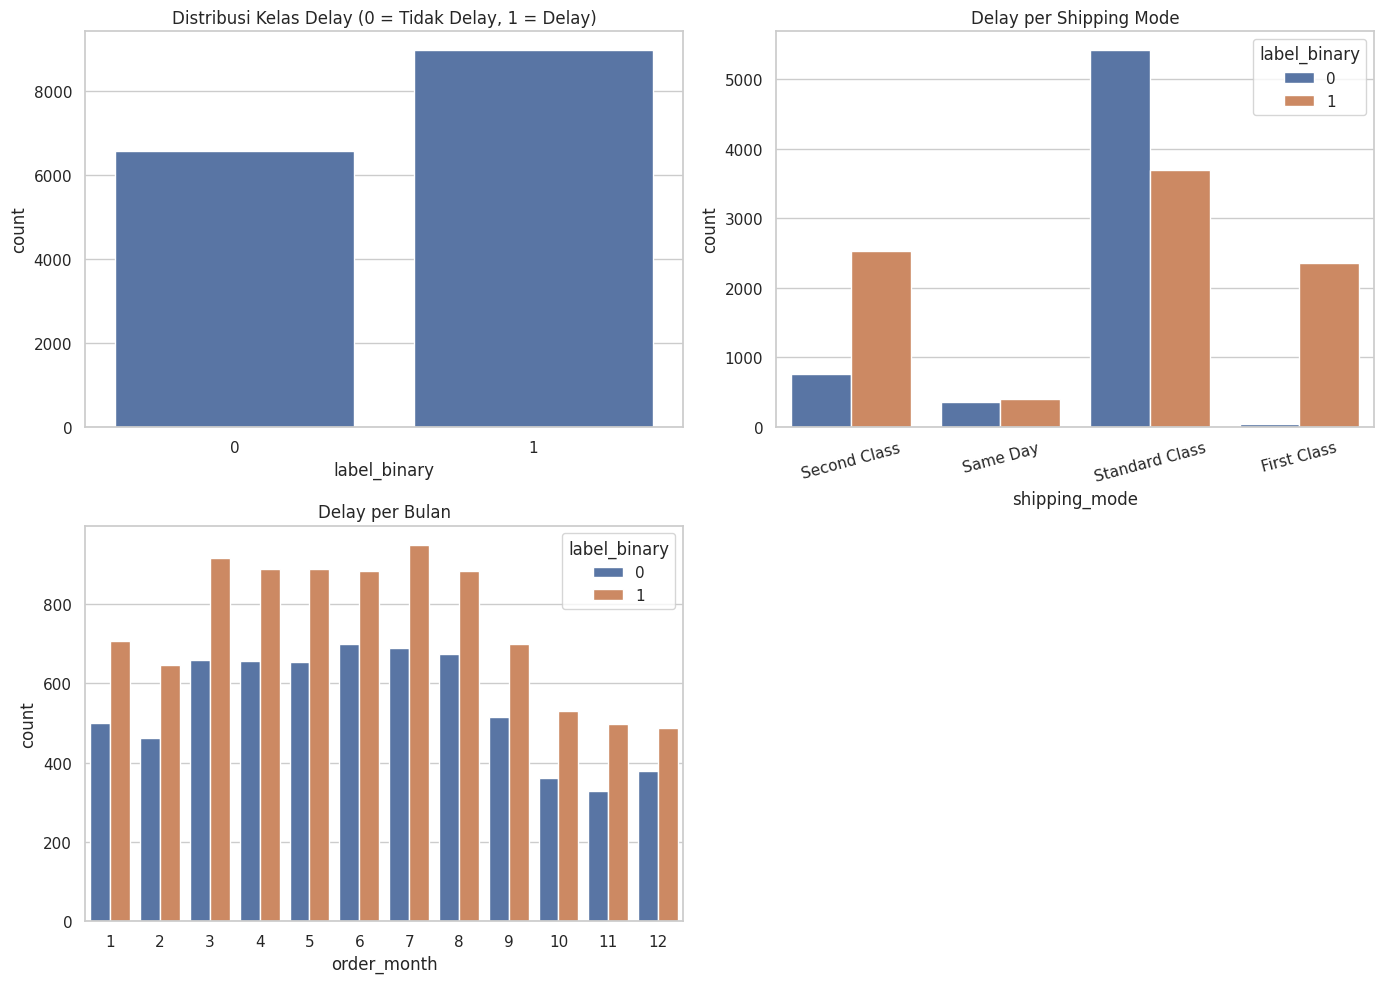

Text(0.5, 1.0, 'Market Vs Delay')

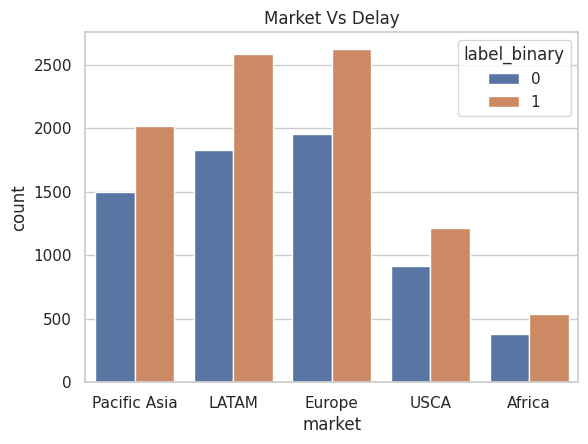

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Buat label binary: hanya anggap 1 sebagai delay
df['label_binary'] = df['label'].apply(lambda x: 1 if x == 1 else 0)

# Pastikan tanggal bisa diproses
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping_date'], errors='coerce')

# Buat fitur tambahan waktu
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['order_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Hitung durasi pengiriman dalam hari
df['shipping_duration'] = (df['shipping_date'] - df['order_date']).dt.days

# Visualisasi
plt.figure(figsize=(14, 10))

# Distribusi kelas delay
plt.subplot(2, 2, 1)
sns.countplot(x='label_binary', data=df)
plt.title('Distribusi Kelas Delay (0 = Tidak Delay, 1 = Delay)')

# Delay per shipping mode
plt.subplot(2, 2, 2)
sns.countplot(x='shipping_mode', hue='label_binary', data=df)
plt.title('Delay per Shipping Mode')
plt.xticks(rotation=15)

# Delay per bulan
plt.subplot(2, 2, 3)
sns.countplot(x='order_month', hue='label_binary', data=df)
plt.title('Delay per Bulan')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))

# Market Vs Delay
plt.subplot(2, 2, 3)
sns.countplot(x='market', hue='label_binary', data=df)
plt.title('Market Vs Delay')


Random Forest menonjol dengan F1-Score terbaik, memberikan keseimbangan yang lebih baik antara precision dan recall, meskipun accuracy-nya sedikit lebih rendah dari Logistic Regression.

K-Nearest Neighbors menduduki posisi kedua, dengan recall yang baik tetapi sedikit lebih rendah dalam precision dibandingkan Random Forest.

Logistic Regression memiliki accuracy tertinggi, namun karena precision-nya rendah, model ini ter-ranking paling bawah di antara ketiga model.

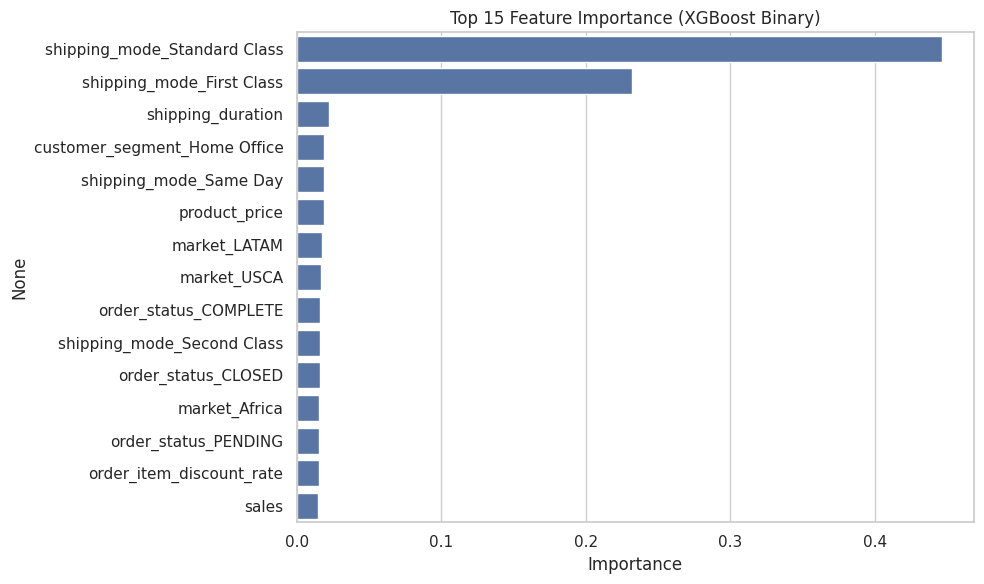

In [24]:
# Ambil nama fitur dari preprocessor
ohe_bin = preprocessor.named_transformers_['cat']
cat_feature_names = ohe_bin.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Feature importance
importances_bin = xgb_bin.feature_importances_
feat_imp_bin = pd.Series(importances_bin, index=all_feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp_bin.values[:15], y=feat_imp_bin.index[:15])
plt.title('Top 15 Feature Importance (XGBoost Binary)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
